<a href="https://colab.research.google.com/github/piaseckazaneta/30DayMapChallenge2026/blob/main/Day3_2026_Polygons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import sys
import os
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Montowanie Google Drive
drive.mount('/content/drive')

# 2. Ścieżka do Twojego folderu projektu
PROJECT_DIR = '/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/'

# Dodajemy folder do sys.path, żeby Python widział layout_engine.py
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# 3. Importujemy nasz layout
from layout_engine import setup_linkedin_canvas, finalize_and_save_linkedin_map

Mounted at /content/drive


In [2]:
# 4. Ścieżka do danych
DATA_DIR = f"{PROJECT_DIR}/Data"

# Wczytanie bazy w metrach (EPSG:2180)
pipeline_gdf = gpd.read_parquet(f"{DATA_DIR}/warszawa_retail_pipeline_final.parquet").to_crs(2180)

# 5. Wydzielenie punktów sieci własnej (50 placówek)
own_stores_pts = pipeline_gdf[pipeline_gdf['has_own_store'] == True].copy()
own_stores_pts['geometry'] = own_stores_pts.geometry.centroid

In [8]:
!pip install -q osmnx
import osmnx as ox
# 6. Pobieramy oficjalną granicę administracyjną Warszawy jako poligon
# Używamy geocodingu OSMnx
warszawa_admin = ox.geocode_to_gdf("Warszawa, Poland")

# 7. Bardzo ważne: reprojekcja do naszego układu metrycznego!
warszawa_admin = warszawa_admin.to_crs("EPSG:2180")

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import voronoi_diagram
from shapely.geometry import MultiPoint
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

# 1. Tworzymy obiekt MultiPoint z geometrii 50 sklepów
multipoint_stores = MultiPoint(own_stores_pts.geometry.tolist())

# 2. Generujemy diagram Woronoja
# shapely.ops.voronoi_diagram generuje kolekcję poligonów
voronoi_geom = voronoi_diagram(multipoint_stores)

# 3. Konwertujemy wynik do GeoDataFrame w metrach
voronoi_gdf = gpd.GeoDataFrame(
    geometry=list(voronoi_geom.geoms),
    crs=own_stores_pts.crs
)

# 4. KROK KRYTYCZNY: Przycinamy nieskończone poligony do granic Warszawy
# Wskazówka: metoda GeoPandas służąca do przycinania to .clip(...)
voronoi_clipped = voronoi_gdf.clip(warszawa_admin)

print(f"Wygenerowano i przycięto {len(voronoi_clipped)} poligonów stref wpływu!")

Wygenerowano i przycięto 50 poligonów stref wpływu!


[Export] Saved clean executive map to: day_03_polygons_warsaw.png


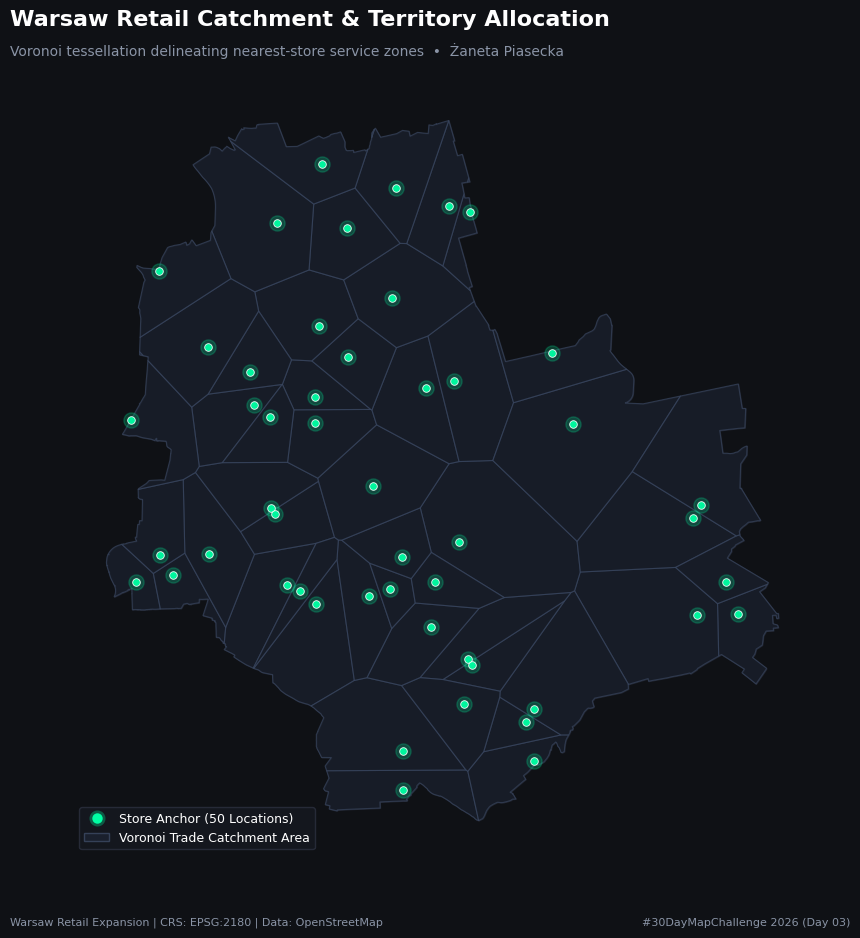

In [10]:
# Inicjalizacja canvasu
fig, ax = setup_linkedin_canvas(aspect_ratio="square")

# Warstwa 0: Obrys administracyjny
warszawa_admin.plot(
    ax=ax,
    facecolor="#12141A",
    edgecolor="#222733",
    linewidth=0.8,
    zorder=1
)

# Warstwa 1: Poligony Woronoja (Strefy wpływu)
voronoi_clipped.plot(
    ax=ax,
    facecolor="#1C2331",
    edgecolor="#3D4B66",
    linewidth=0.8,
    alpha=0.6,
    zorder=2
)

# Warstwa 2: Sklepy sieci (Glow + Rdzeń) - na wierzchu!
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    markersize=120,
    alpha=0.20,
    zorder=3
)
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    edgecolor="#FFFFFF",
    linewidth=0.6,
    markersize=30,
    alpha=0.95,
    zorder=4
)

# 3. Legenda zgodna z kanonem: Punkty (0D) -> Poligony (2D)
mint_hex = "#00FFA3"
mint_glow_rgba = to_rgba(mint_hex, alpha=0.30)

custom_handles = [
    # Punkt (0D)
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=f'Store Anchor ({len(own_stores_pts)} Locations)',
        markerfacecolor=mint_hex,
        markeredgecolor=mint_glow_rgba,
        markeredgewidth=4.0,
        markersize=7.5
    ),
    # Poligon (2D) - używamy Patch!
    Patch(
        facecolor="#1C2331",
        edgecolor="#3D4B66",
        linewidth=1.0,
        alpha=0.8,
        label="Voronoi Trade Catchment Area"
    )
]

legend = ax.legend(
    handles=custom_handles,
    loc="lower left",
    frameon=True,
    facecolor="#161920",
    edgecolor="#2A2F3D",
    fontsize=9,
    labelcolor="#FFFFFF"
)
legend.get_frame().set_alpha(0.85)

# 4. Finalizacja i eksport
finalize_and_save_linkedin_map(
    fig=fig,
    ax=ax,
    main_title="Warsaw Retail Catchment & Territory Allocation",
    subtitle="Voronoi tessellation delineating nearest-store service zones",
    author_name="Żaneta Piasecka",
    day_num=3,
    output_filename="day_03_polygons_warsaw.png"
)

plt.show()